# 03: Geoprocessing


## Import libraries


In [2]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, Point, LineString
import pandas as pd
import numpy as np

import folium
from folium import plugins

from shapely.geometry import Point, Polygon, LineString
from shapely.ops import unary_union
import contextily as ctx

plt.style.use("default")

In [4]:
plt.rcParams["figure.figsize"] = (10, 10)


def set_axis_off():
    """
    Set the default matplotlib settings to turn off axes and ticks.
    This function modifies the global matplotlib configuration to hide axes and ticks
    for all plots created after this function is called.
    """
    # set axis off by default
    plt.rcParams["axes.axisbelow"] = False
    plt.rcParams["axes.spines.left"] = False
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.bottom"] = False

    # set tick params off by default
    plt.rcParams["xtick.bottom"] = False
    plt.rcParams["xtick.top"] = False
    plt.rcParams["xtick.labelbottom"] = False
    plt.rcParams["xtick.labeltop"] = False
    plt.rcParams["ytick.left"] = False
    plt.rcParams["ytick.right"] = False
    plt.rcParams["ytick.labelleft"] = False
    plt.rcParams["ytick.labelright"] = False


# Apply the settings
set_axis_off()

In [ ]:
cafes = gpd.read_file(
    "/Users/jayce/datamapping/cdp_datamapping_system/cdp-mapping-systems/Data/cafe.geojson"
)
museums = gpd.read_file(
    "/Users/jayce/datamapping/cdp_datamapping_system/cdp-mapping-systems/Data/museum.geojson"
)
subway = gpd.read_file(
    "/Users/jayce/datamapping/cdp_datamapping_system/cdp-mapping-systems/Data/MTA_Subway_Stations_and_Complexes_20250710.csv"
)

print("Cafes shape:", cafes.shape)
print("Museums shape:", museums.shape)
print("Subway shape:", subway.shape)

Cafes shape: (11, 3)
Museums shape: (6, 2)
Subway shape: (445, 16)


In [15]:
# 각 데이터셋의 구조 확인
print("=== CAFES ===")
print(cafes.head())
print("\nColumns:", cafes.columns.tolist())

print("\n=== MUSEUMS ===")
print(museums.head())
print("\nColumns:", museums.columns.tolist())

print("\n=== SUBWAY ===")
print(subway.head())
print("\nColumns:", subway.columns.tolist())

=== CAFES ===
                        name                                  notes  \
0        Conwell Coffee Hall                Spacious, outlets, WiFi   
1               Bibliotheque             Book-themed, WiFi, outlets   
2               Caffe Reggio      Historic cafe, classic vibe, WiFi   
3  The Hungarian Pastry Shop  Cultural, writing atmosphere, no WiFi   
4      Remi Flowers & Coffee          Flowers & coffee, quiet space   

                   geometry  
0  POINT (-74.0062 40.7074)  
1  POINT (-74.0006 40.7242)  
2  POINT (-74.0001 40.7301)  
3  POINT (-73.9637 40.8037)  
4  POINT (-73.9701 40.7579)  

Columns: ['name', 'notes', 'geometry']

=== MUSEUMS ===
                             name                  geometry
0                            MoMA  POINT (-73.9776 40.7614)
1                  Whitney Museum  POINT (-74.0089 40.7396)
2               Guggenheim Museum    POINT (-73.959 40.783)
3            Cooper Hewitt Museum   POINT (-73.958 40.7844)
4  The Metropolitan Mu

In [17]:
from shapely.geometry import Point

# Convert CSV to GeoDataFrame
geometry = [Point(xy) for xy in zip(subway["Longitude"], subway["Latitude"])]
subway = gpd.GeoDataFrame(subway, geometry=geometry, crs="EPSG:4326")

print("=== After conversion ===")
print("Subway type:", type(subway))
print("Subway CRS:", subway.crs)
print("Geometry column created:", "geometry" in subway.columns)

=== After conversion ===
Subway type: <class 'geopandas.geodataframe.GeoDataFrame'>
Subway CRS: EPSG:4326
Geometry column created: True


In [18]:
print("=== CRS INFO (All datasets) ===")
print("Cafes CRS:", cafes.crs)
print("Museums CRS:", museums.crs)
print("Subway CRS:", subway.crs)

# Ensure all datasets use the same CRS (WGS84)
cafes = cafes.to_crs("EPSG:4326")
museums = museums.to_crs("EPSG:4326")
# subway is already set to 4326

print("\n=== After CRS alignment ===")
print("Cafes CRS:", cafes.crs)
print("Museums CRS:", museums.crs)
print("Subway CRS:", subway.crs)

=== CRS INFO (All datasets) ===
Cafes CRS: EPSG:4326
Museums CRS: EPSG:4326
Subway CRS: EPSG:4326

=== After CRS alignment ===
Cafes CRS: EPSG:4326
Museums CRS: EPSG:4326
Subway CRS: EPSG:4326


In [20]:
print("=== CAFES ===")
print("Columns:", cafes.columns.tolist())
if len(cafes.columns) > 1:
    for col in cafes.columns:
        if col != "geometry":
            print(f"{col} values:")
            print(cafes[col].value_counts())
            print()

print("=== MUSEUMS ===")
print("Columns:", museums.columns.tolist())
if len(museums.columns) > 1:
    for col in museums.columns:
        if col != "geometry":
            print(f"{col} values:")
            print(museums[col].value_counts())
            print()

print("=== SUBWAY ===")
print("Some interesting columns to explore:")
print("Borough distribution:")
print(subway["Borough"].value_counts())
print()

print("Structure Type distribution:")
print(subway["Structure Type"].value_counts())
print()

print("Daytime Routes (top 10):")
print(subway["Daytime Routes"].value_counts().head(10))

=== CAFES ===
Columns: ['name', 'notes', 'geometry']
name values:
name
Conwell Coffee Hall               1
Bibliotheque                      1
Caffe Reggio                      1
The Hungarian Pastry Shop         1
Remi Flowers & Coffee             1
Paper Coffee                      1
The Lost Draft                    1
NY Public Library - Schwarzman    1
Watch House NY                    1
12 Matcha                         1
Silence Please                    1
Name: count, dtype: int64

notes values:
notes
Spacious, outlets, WiFi                  1
Book-themed, WiFi, outlets               1
Historic cafe, classic vibe, WiFi        1
Cultural, writing atmosphere, no WiFi    1
Flowers & coffee, quiet space            1
Highly rated, study-friendly             1
Cozy, WiFi, study-friendly               1
Public study space, quiet, WiFi          1
Modern, spacious, WiFi                   1
Matcha specialist cafe, quiet, WiFi      1
Quiet workspace, study-focused cafe      1
Name: count, 

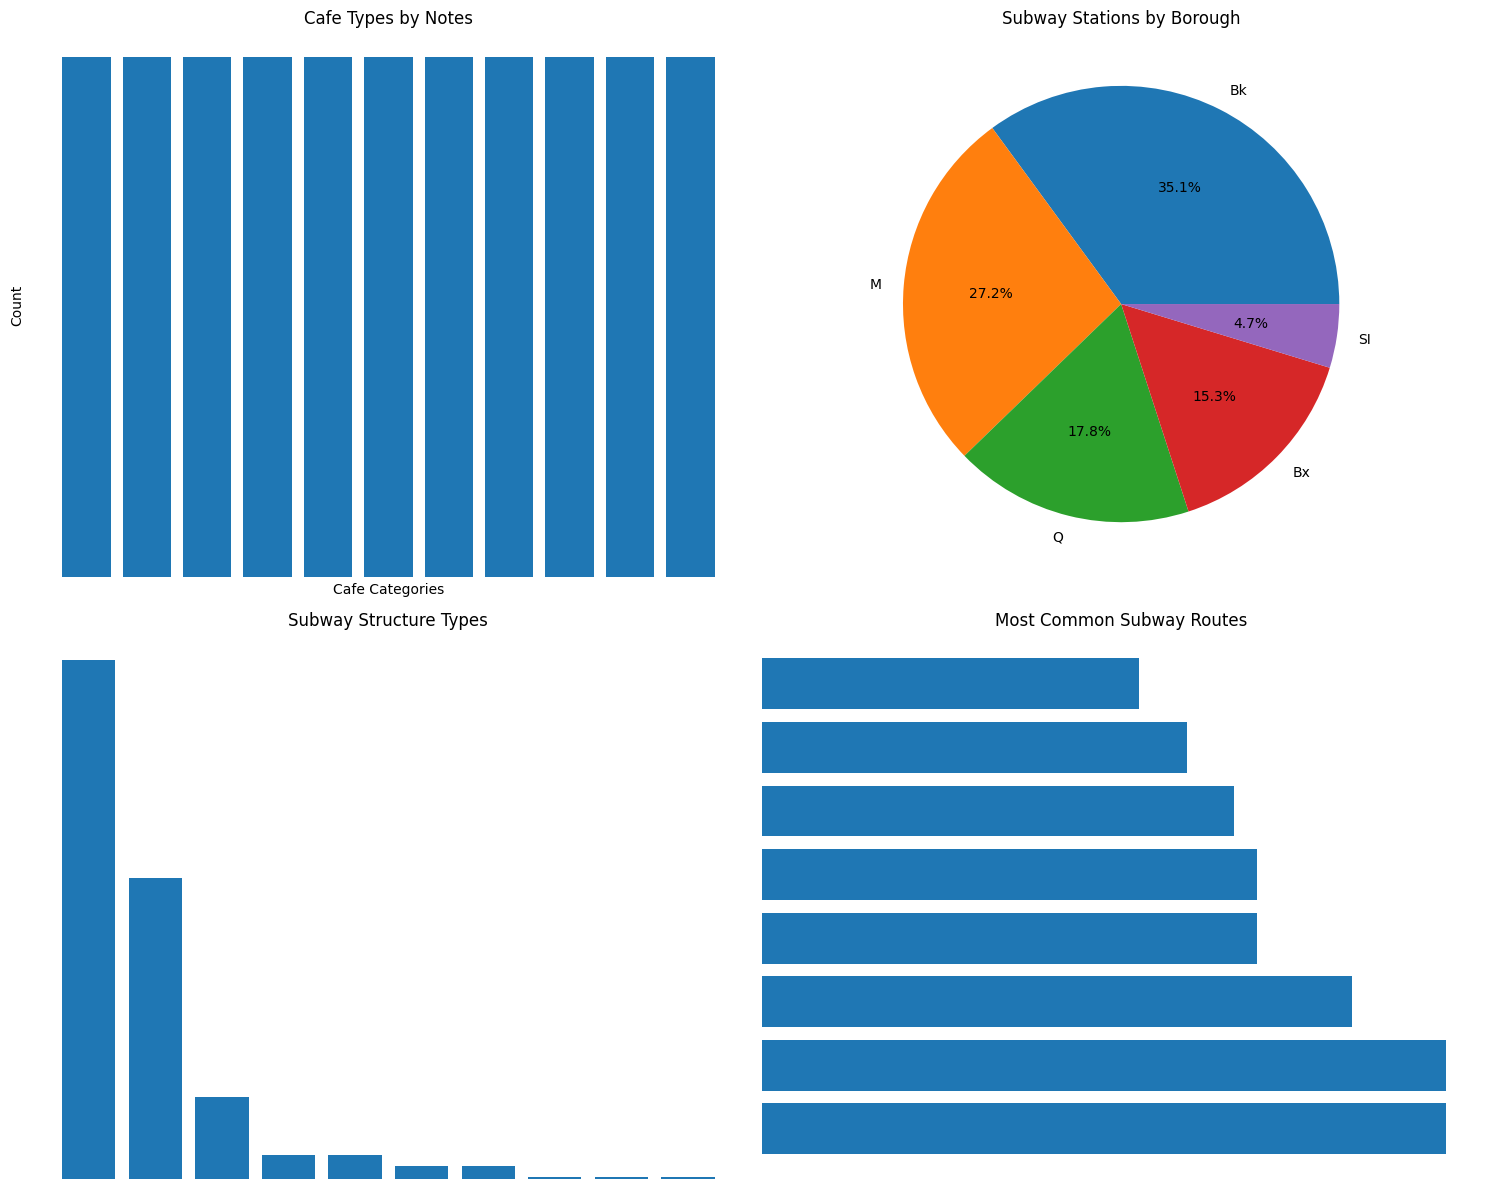

In [21]:
# Visualize the categorical data
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Cafe notes analysis
cafe_notes = cafes["notes"].value_counts()
axes[0, 0].bar(range(len(cafe_notes)), cafe_notes.values)
axes[0, 0].set_title("Cafe Types by Notes")
axes[0, 0].set_xlabel("Cafe Categories")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Borough distribution
borough_counts = subway["Borough"].value_counts()
axes[0, 1].pie(borough_counts.values, labels=borough_counts.index, autopct="%1.1f%%")
axes[0, 1].set_title("Subway Stations by Borough")

# 3. Structure types
structure_counts = subway["Structure Type"].value_counts()
axes[1, 0].bar(structure_counts.index, structure_counts.values)
axes[1, 0].set_title("Subway Structure Types")
axes[1, 0].tick_params(axis="x", rotation=45)

# 4. Top subway routes
top_routes = subway["Daytime Routes"].value_counts().head(8)
axes[1, 1].barh(range(len(top_routes)), top_routes.values)
axes[1, 1].set_yticks(range(len(top_routes)))
axes[1, 1].set_yticklabels(top_routes.index)
axes[1, 1].set_title("Most Common Subway Routes")

plt.tight_layout()
plt.show()

In [22]:
import folium

m = folium.Map(location=[40.7128, -74.0060], zoom_start=12)

cafes.explore(
    m=m,
    color="brown",
    marker_kwds={"radius": 8},
    tooltip=["name", "notes"],
    popup=["name"],
    name="Cafes",
)

museums.explore(
    m=m,
    color="blue",
    marker_kwds={"radius": 8},
    tooltip=["name"],
    popup=["name"],
    name="Museums",
)

subway.sample(100).explore(
    m=m,
    color="gray",
    marker_kwds={"radius": 3},
    tooltip=["Stop Name", "Borough"],
    name="Subway",
)

folium.LayerControl().add_to(m)

m

In [23]:
cafe_bounds = cafes.total_bounds
museum_bounds = museums.total_bounds
subway_bounds = subway.total_bounds

print("=== BOUNDING BOXES ===")
print(f"Cafes bounds: {cafe_bounds}")
print(f"Museums bounds: {museum_bounds}")
print(f"Subway bounds: {subway_bounds}")

import numpy as np

all_bounds = np.array([cafe_bounds, museum_bounds, subway_bounds])
combined_bounds = [
    all_bounds[:, 0].min(),  # min x (longitude)
    all_bounds[:, 1].min(),  # min y (latitude)
    all_bounds[:, 2].max(),  # max x (longitude)
    all_bounds[:, 3].max(),  # max y (latitude)
]

print(f"\nCombined bounds for all data: {combined_bounds}")

# You can also create a bounding box geometry
from shapely.geometry import box

bounds_geometry = box(*combined_bounds)
print(f"Bounding box area: {bounds_geometry}")

# Create a GeoDataFrame with the bounding box
bounds_gdf = gpd.GeoDataFrame([1], geometry=[bounds_geometry], crs="EPSG:4326")

=== BOUNDING BOXES ===
Cafes bounds: [-74.0062  40.7074 -73.9637  40.8037]
Museums bounds: [-74.0089  40.7223 -73.958   40.7844]
Subway bounds: [-74.251961  40.512764 -73.755405  40.903125]

Combined bounds for all data: [np.float64(-74.251961), np.float64(40.512764), np.float64(-73.755405), np.float64(40.903125)]
Bounding box area: POLYGON ((-73.755405 40.512764, -73.755405 40.903125, -74.251961 40.903125, -74.251961 40.512764, -73.755405 40.512764))


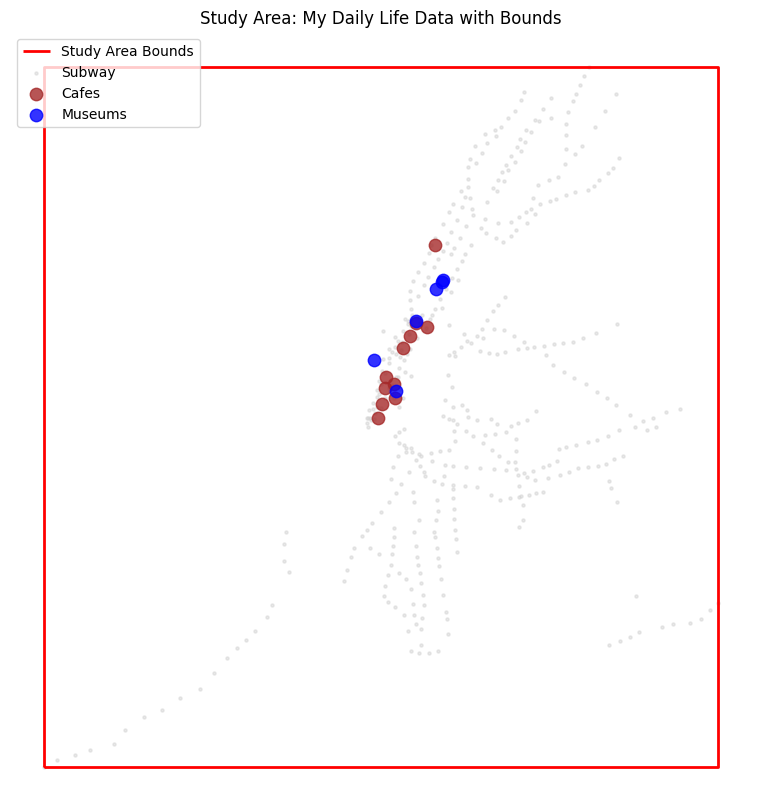

In [24]:
fig, ax = plt.subplots(figsize=(12, 10))

bounds_gdf.boundary.plot(ax=ax, color="red", linewidth=2, label="Study Area Bounds")


subway.plot(ax=ax, color="lightgray", markersize=5, alpha=0.5, label="Subway")
cafes.plot(ax=ax, color="brown", markersize=80, alpha=0.8, label="Cafes")
museums.plot(ax=ax, color="blue", markersize=80, alpha=0.8, label="Museums")

plt.legend()
plt.title("Study Area: My Daily Life Data with Bounds")
plt.show()

Let's visually inspect the bounds of our daily life data.


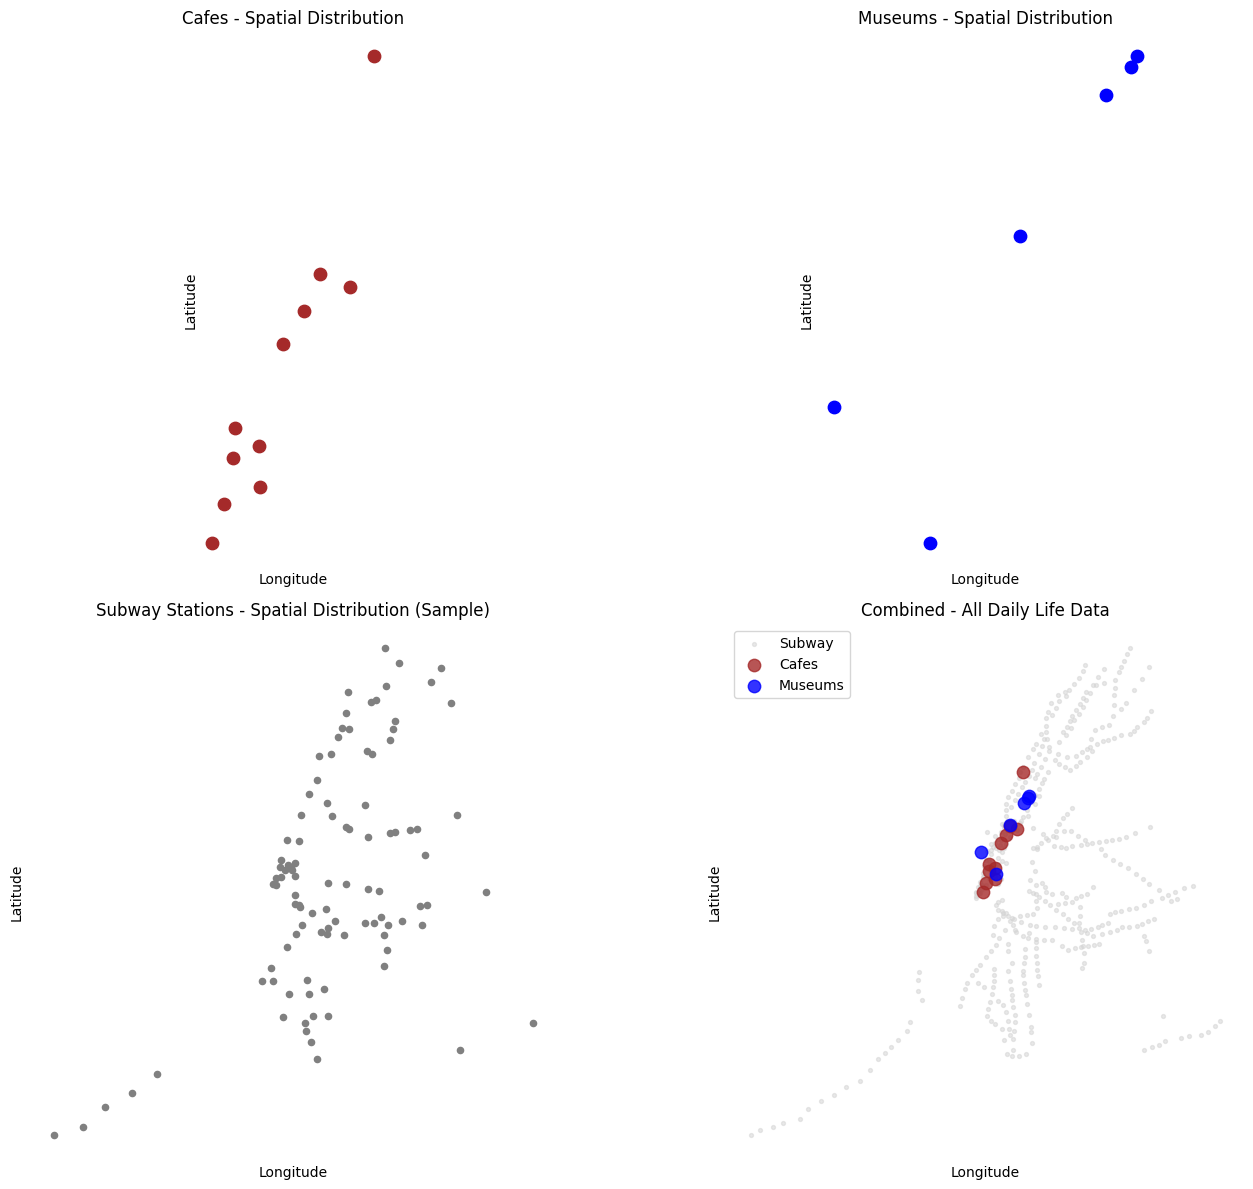


Cafes bounds: [-74.0062  40.7074 -73.9637  40.8037]
Museums bounds: [-74.0089  40.7223 -73.958   40.7844]
Subway bounds: [-74.251961  40.512764 -73.755405  40.903125]


In [26]:
print("Let's visually inspect the bounds of our daily life data.")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

cafes.plot(ax=axes[0, 0], color="brown", markersize=80)
axes[0, 0].set_title("Cafes - Spatial Distribution")
axes[0, 0].set_xlabel("Longitude")
axes[0, 0].set_ylabel("Latitude")

museums.plot(ax=axes[0, 1], color="blue", markersize=80)
axes[0, 1].set_title("Museums - Spatial Distribution")
axes[0, 1].set_xlabel("Longitude")
axes[0, 1].set_ylabel("Latitude")

subway.sample(100).plot(ax=axes[1, 0], color="gray", markersize=20)
axes[1, 0].set_title("Subway Stations - Spatial Distribution (Sample)")
axes[1, 0].set_xlabel("Longitude")
axes[1, 0].set_ylabel("Latitude")

subway.plot(ax=axes[1, 1], color="lightgray", markersize=8, alpha=0.5, label="Subway")
cafes.plot(ax=axes[1, 1], color="brown", markersize=80, alpha=0.8, label="Cafes")
museums.plot(ax=axes[1, 1], color="blue", markersize=80, alpha=0.8, label="Museums")
axes[1, 1].set_title("Combined - All Daily Life Data")
axes[1, 1].set_xlabel("Longitude")
axes[1, 1].set_ylabel("Latitude")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\nCafes bounds: {cafes.total_bounds}")
print(f"Museums bounds: {museums.total_bounds}")
print(f"Subway bounds: {subway.total_bounds}")

In [27]:
bounds = combined_bounds

# Convert bounds array to polygon
bounds_poly = gpd.GeoSeries(
    Polygon(
        [
            [bounds[0], bounds[1]],  # bottom-left
            [bounds[0], bounds[3]],  # top-left
            [bounds[2], bounds[3]],  # top-right
            [bounds[2], bounds[1]],  # bottom-right
            [bounds[0], bounds[1]],  # close the polygon
        ]
    ),
    crs=cafes.crs,  # Use the same CRS as our data
)

print("Bounds polygon created:")
print(bounds_poly)
print(f"CRS: {bounds_poly.crs}")
print(f"Bounds: {bounds}")

Bounds polygon created:
0    POLYGON ((-74.25196 40.51276, -74.25196 40.903...
dtype: geometry
CRS: EPSG:4326
Bounds: [np.float64(-74.251961), np.float64(40.512764), np.float64(-73.755405), np.float64(40.903125)]


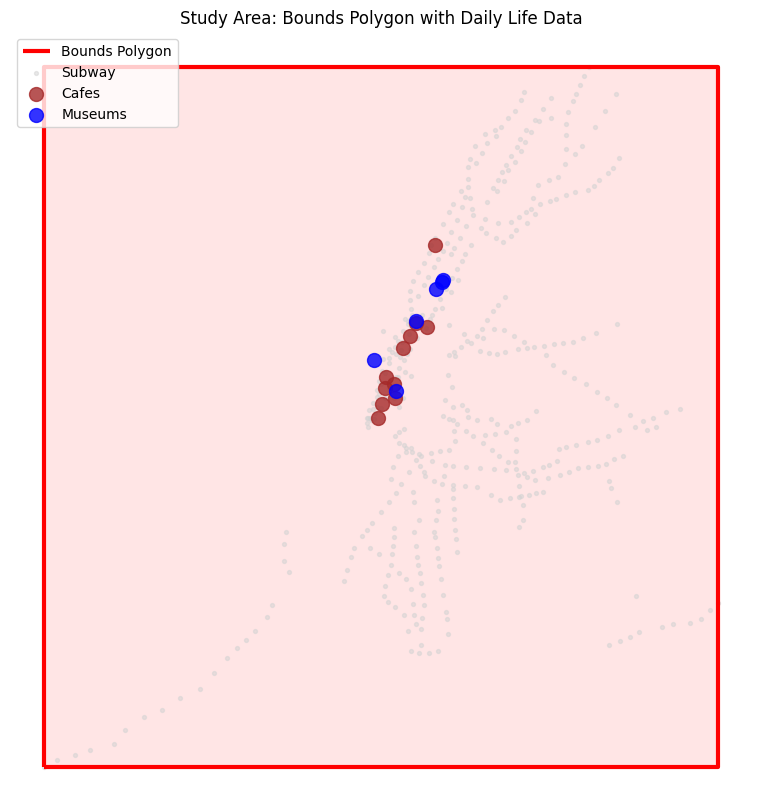

In [28]:
# Visualize the bounds polygon with our data
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the bounds polygon
bounds_poly.boundary.plot(ax=ax, color="red", linewidth=3, label="Bounds Polygon")
bounds_poly.plot(ax=ax, color="red", alpha=0.1)

# Plot our data inside the bounds
subway.plot(ax=ax, color="lightgray", markersize=8, alpha=0.5, label="Subway")
cafes.plot(ax=ax, color="brown", markersize=100, alpha=0.8, label="Cafes")
museums.plot(ax=ax, color="blue", markersize=100, alpha=0.8, label="Museums")

plt.legend()
plt.title("Study Area: Bounds Polygon with Daily Life Data")
plt.show()

Now we can see that the bounds are a polygon that covers the entire area of interest.


In [29]:
bounds_poly.explore()

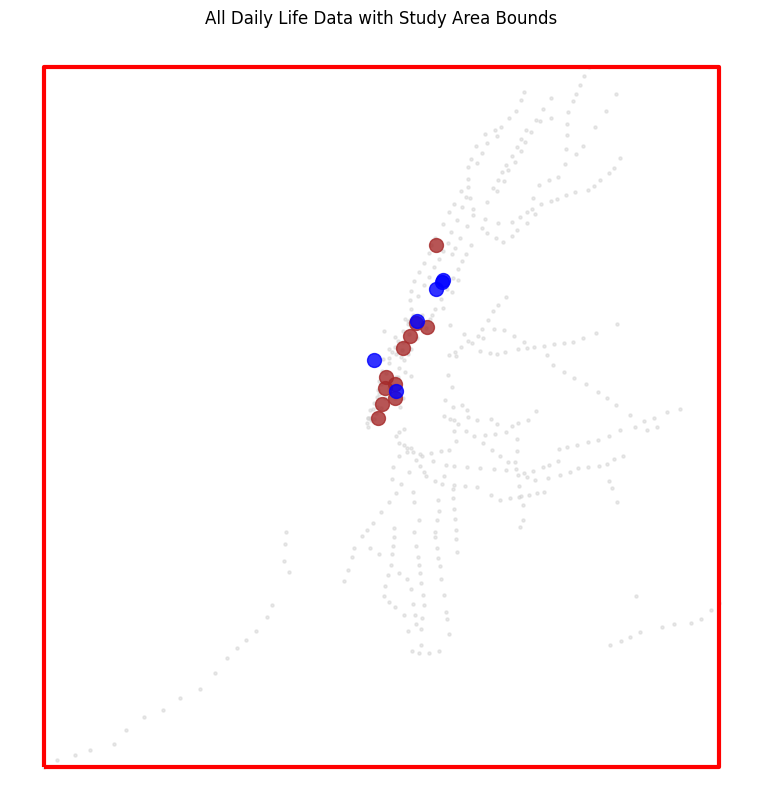

In [32]:
# Plot all data with bounds
ax = subway.plot(color="lightgray", markersize=5, alpha=0.5, figsize=(12, 10))
cafes.plot(ax=ax, color="brown", markersize=100, alpha=0.8)
museums.plot(ax=ax, color="blue", markersize=100, alpha=0.8)
bounds_poly.boundary.plot(ax=ax, color="red", linewidth=3)

plt.title("All Daily Life Data with Study Area Bounds")
plt.show()

In [33]:
print("=== CRS Information ===")
print("Cafes CRS:", cafes.crs)
print("Museums CRS:", museums.crs)
print("Subway CRS:", subway.crs)
print("Bounds polygon CRS:", bounds_poly.crs)

=== CRS Information ===
Cafes CRS: EPSG:4326
Museums CRS: EPSG:4326
Subway CRS: EPSG:4326
Bounds polygon CRS: EPSG:4326


In [34]:
bounds_poly.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [36]:
bounds_poly_wgs84 = bounds_poly.to_crs("EPSG:4326")

In [37]:
bounds_poly_wgs84.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
cb_307_bldgs = gpd.read_file(
    "../Data/bldg_footprints/Building Footprints.geojson",
    mask=bounds_poly_wgs84[0],
)

In [38]:
subway_in_bounds = subway[subway.within(bounds_poly_wgs84[0])]

print(f"Original subway stations: {len(subway)}")
print(f"Subway stations in study area: {len(subway_in_bounds)}")

Original subway stations: 445
Subway stations in study area: 442


In [39]:
subway_in_bounds.explore()

In [40]:
subway_manhattan = subway_in_bounds[subway_in_bounds["Borough"] == "M"]
print(f"Manhattan subway stations: {len(subway_manhattan)}")

cafes_with_wifi = cafes[cafes["notes"].str.contains("WiFi", na=False)]
print(f"Cafes with WiFi: {len(cafes_with_wifi)}")

Manhattan subway stations: 121
Cafes with WiFi: 8


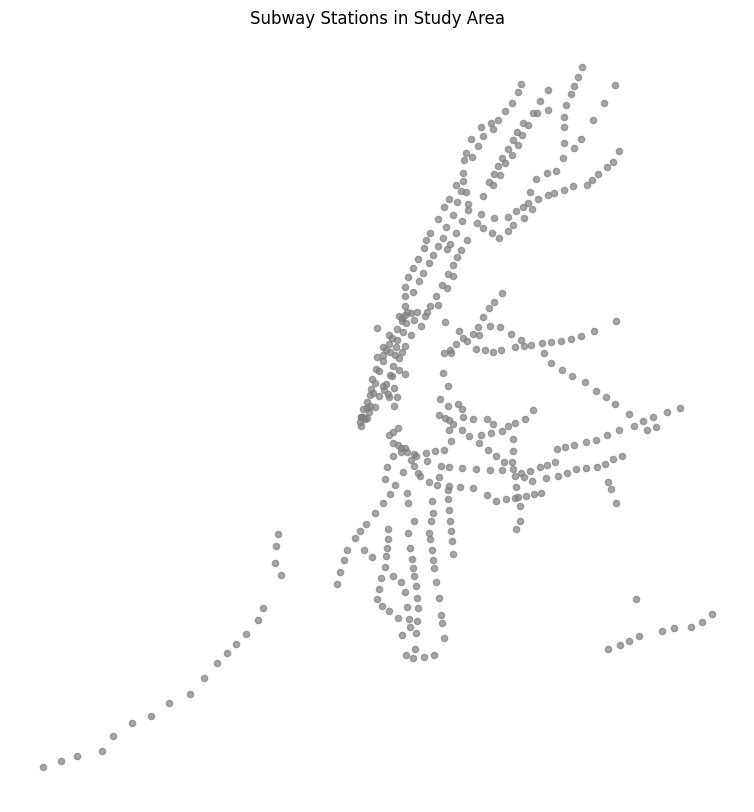

In [41]:
subway_in_bounds.plot(figsize=(10, 10), color="gray", markersize=20, alpha=0.7)
plt.title("Subway Stations in Study Area")
plt.show()

## Combine building footprints and tax lot data


To combine our cafes and museums with subway accessibility,
we will compare the spatial relations between the point locations.
We want to find which subway stations are closest to our daily life locations.

Sample cafe: 12 Matcha
Location: POINT (-73.9939 40.7265)


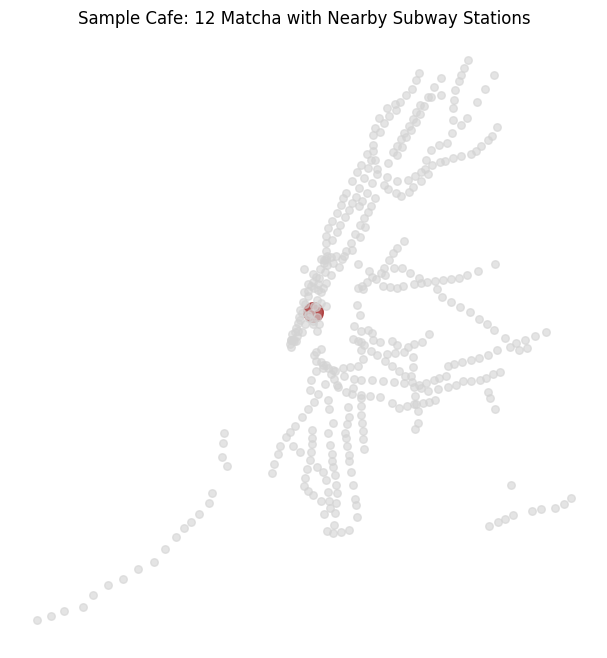

In [42]:
# "To combine our point datasets with subway network accessibility"

print("To combine our cafes and museums with subway accessibility,")
print("we will compare the spatial relations between the point locations.")
print("We want to find which subway stations are closest to our daily life locations.")

sample_cafe = cafes.sample(1)

print(f"\nSample cafe: {sample_cafe['name'].iloc[0]}")
print(f"Location: {sample_cafe.geometry.iloc[0]}")

ax = sample_cafe.plot(color="brown", markersize=200, alpha=0.8, figsize=(10, 8))

nearby_subway = subway_in_bounds.plot(
    ax=ax, color="lightgray", markersize=30, alpha=0.6
)

plt.title(f'Sample Cafe: {sample_cafe["name"].iloc[0]} with Nearby Subway Stations')
plt.show()

In [46]:
cafes_with_rep_pt = cafes.copy()
cafes_with_rep_pt["rep_pt"] = cafes_with_rep_pt.geometry.copy()
cafes_with_rep_pt.set_geometry("rep_pt", inplace=True)

cafes_with_rep_pt.head()

,name,notes,geometry,rep_pt
0,Conwell Coffee Hall,"Spacious, outlets, WiFi",POINT (-74.0062 40.7074),POINT (-74.0062 40.7074)
1,Bibliotheque,"Book-themed, WiFi, outlets",POINT (-74.0006 40.7242),POINT (-74.0006 40.7242)
2,Caffe Reggio,"Historic cafe, classic vibe, WiFi",POINT (-74.0001 40.7301),POINT (-74.0001 40.7301)
3,The Hungarian Pastry Shop,"Cultural, writing atmosphere, no WiFi",POINT (-73.9637 40.8037),POINT (-73.9637 40.8037)
4,Remi Flowers & Coffee,"Flowers & coffee, quiet space",POINT (-73.9701 40.7579),POINT (-73.9701 40.7579)


In [48]:
subway_with_rep_pt = subway_in_bounds.copy()
subway_with_rep_pt["rep_pt"] = subway_with_rep_pt.geometry.copy()
subway_with_rep_pt.set_geometry("rep_pt", inplace=True)

print("subway_with_rep_pt created")
print(f"Shape: {subway_with_rep_pt.shape}")

subway_with_rep_pt created
Shape: (442, 18)


In [49]:
from shapely.ops import nearest_points
import numpy as np


def find_nearest_subway(cafe_point, subway_gdf):
    distances = subway_gdf.geometry.distance(cafe_point)
    nearest_idx = distances.idxmin()
    return subway_gdf.loc[nearest_idx]


nearest_subway_info = []
for idx, cafe in cafes_with_rep_pt.iterrows():
    nearest = find_nearest_subway(cafe.geometry, subway_with_rep_pt)
    nearest_subway_info.append(
        {
            "cafe_name": cafe["name"],
            "nearest_station": nearest["Stop Name"],
            "nearest_borough": nearest["Borough"],
            "distance_meters": cafe.geometry.distance(nearest.geometry) * 111000,
        }
    )

import pandas as pd

cafe_subway_join = pd.DataFrame(nearest_subway_info)
print("Cafes with nearest subway stations:")
cafe_subway_join.head()

Cafes with nearest subway stations:


/var/folders/44/049vwny176x1nrnv4c1p88r80000gn/T/ipykernel_70713/2167919898.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = subway_gdf.geometry.distance(cafe_point)
/var/folders/44/049vwny176x1nrnv4c1p88r80000gn/T/ipykernel_70713/2167919898.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = subway_gdf.geometry.distance(cafe_point)
/var/folders/44/049vwny176x1nrnv4c1p88r80000gn/T/ipykernel_70713/2167919898.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = subway_gdf.geometry.distance(cafe_point)
/var/folders/44/049vwny176x1nrnv4c

,cafe_name,nearest_station,nearest_borough,distance_meters
0,Conwell Coffee Hall,Wall St,M,328.253125
1,Bibliotheque,Prince St,M,321.996536
2,Caffe Reggio,W 4 St-Wash Sq,M,252.257580
3,The Hungarian Pastry Shop,Cathedral Pkwy (110 St),M,350.571987
4,Remi Flowers & Coffee,Lexington Av/51-53 Sts,M,76.551905


In [53]:
subway_with_rep_pt = subway_in_bounds.copy()
subway_with_rep_pt["rep_pt"] = subway_with_rep_pt.geometry.copy()
subway_with_rep_pt.set_geometry("rep_pt", inplace=True)

cafes_w_nearest_subway = cafes_with_rep_pt.sjoin_nearest(
    subway_with_rep_pt, how="left", distance_col="distance"
)

cafes_w_nearest_subway[["name", "notes", "Stop Name", "Borough", "distance"]].head()

/Users/jayce/conda/envs/cdp_mapping_system/lib/python3.12/site-packages/geopandas/array.py:417: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,name,notes,Stop Name,Borough,distance
0,Conwell Coffee Hall,"Spacious, outlets, WiFi",Wall St,M,0.002957
1,Bibliotheque,"Book-themed, WiFi, outlets",Prince St,M,0.002901
2,Caffe Reggio,"Historic cafe, classic vibe, WiFi",W 4 St-Wash Sq,M,0.002273
3,The Hungarian Pastry Shop,"Cultural, writing atmosphere, no WiFi",Cathedral Pkwy (110 St),M,0.003158
4,Remi Flowers & Coffee,"Flowers & coffee, quiet space",Lexington Av/51-53 Sts,M,0.000690


In [54]:
cafes_w_nearest_subway[
    ["name", "notes", "Stop Name", "Borough", "Daytime Routes", "distance"]
].head()

,name,notes,Stop Name,Borough,Daytime Routes,distance
0,Conwell Coffee Hall,"Spacious, outlets, WiFi",Wall St,M,2 3,0.002957
1,Bibliotheque,"Book-themed, WiFi, outlets",Prince St,M,R W,0.002901
2,Caffe Reggio,"Historic cafe, classic vibe, WiFi",W 4 St-Wash Sq,M,A C E B D F M,0.002273
3,The Hungarian Pastry Shop,"Cultural, writing atmosphere, no WiFi",Cathedral Pkwy (110 St),M,1,0.003158
4,Remi Flowers & Coffee,"Flowers & coffee, quiet space",Lexington Av/51-53 Sts,M,6 E M,0.000690


In [55]:
cafes_w_nearest_subway = cafes_with_rep_pt.sjoin_nearest(
    subway_with_rep_pt, how="left", distance_col="distance"
)

/Users/jayce/conda/envs/cdp_mapping_system/lib/python3.12/site-packages/geopandas/array.py:417: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [56]:
museums_with_rep_pt = museums.copy()
museums_with_rep_pt["rep_pt"] = museums_with_rep_pt.geometry.copy()
museums_with_rep_pt.set_geometry("rep_pt", inplace=True)

museums_w_nearest_subway = museums_with_rep_pt.sjoin_nearest(
    subway_with_rep_pt, how="left", distance_col="distance"
)

/Users/jayce/conda/envs/cdp_mapping_system/lib/python3.12/site-packages/geopandas/array.py:417: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [57]:
print("=== NEAREST SUBWAY STATIONS ===")
print("Cafes:")
print(cafes_w_nearest_subway[["name", "Stop Name", "Borough", "distance"]].head())

print("\nMuseums:")
print(museums_w_nearest_subway[["name", "Stop Name", "Borough", "distance"]].head())

=== NEAREST SUBWAY STATIONS ===
Cafes:
                        name                Stop Name Borough  distance
0        Conwell Coffee Hall                  Wall St       M  0.002957
1               Bibliotheque                Prince St       M  0.002901
2               Caffe Reggio           W 4 St-Wash Sq       M  0.002273
3  The Hungarian Pastry Shop  Cathedral Pkwy (110 St)       M  0.003158
4      Remi Flowers & Coffee   Lexington Av/51-53 Sts       M  0.000690

Museums:
                             name   Stop Name Borough  distance
0                            MoMA       57 St       M  0.002576
1                  Whitney Museum  14 St/8 Av       M  0.006806
2               Guggenheim Museum       86 St       M  0.004893
3            Cooper Hewitt Museum       86 St       M  0.005468
4  The Metropolitan Museum of Art       77 St       M  0.006669


We can plot the distance field to visualize how far each input feature is from a target feature. What do you notice?


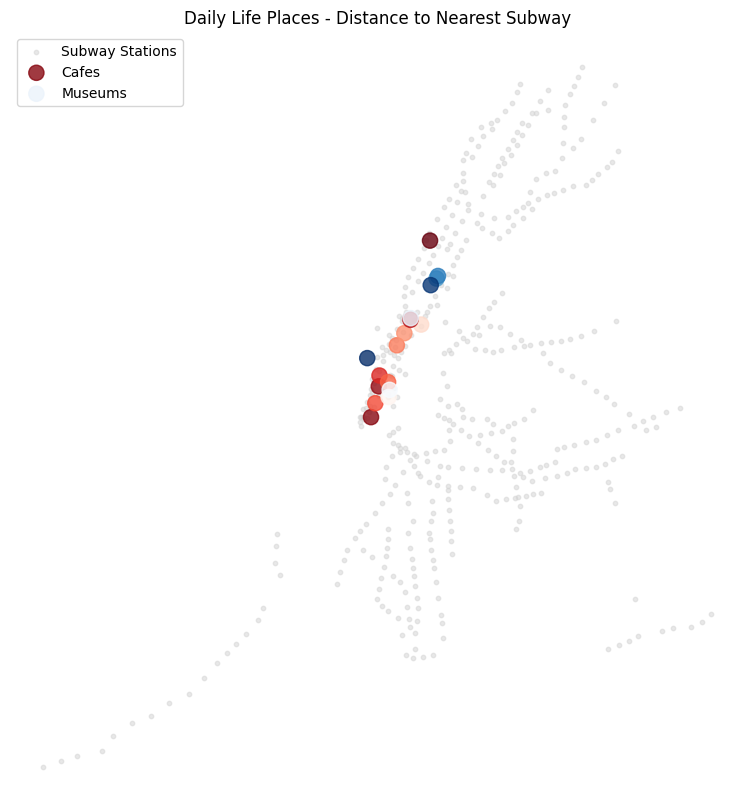

In [59]:
fig, ax = plt.subplots(figsize=(12, 10))

subway_with_rep_pt.plot(
    ax=ax, color="lightgray", markersize=10, alpha=0.5, label="Subway Stations"
)

cafes_w_nearest_subway.plot(
    "distance", ax=ax, markersize=120, alpha=0.8, cmap="Reds", label="Cafes"
)

museums_w_nearest_subway.plot(
    "distance", ax=ax, markersize=120, alpha=0.8, cmap="Blues", label="Museums"
)

plt.title("Daily Life Places - Distance to Nearest Subway")
plt.legend()
plt.show()

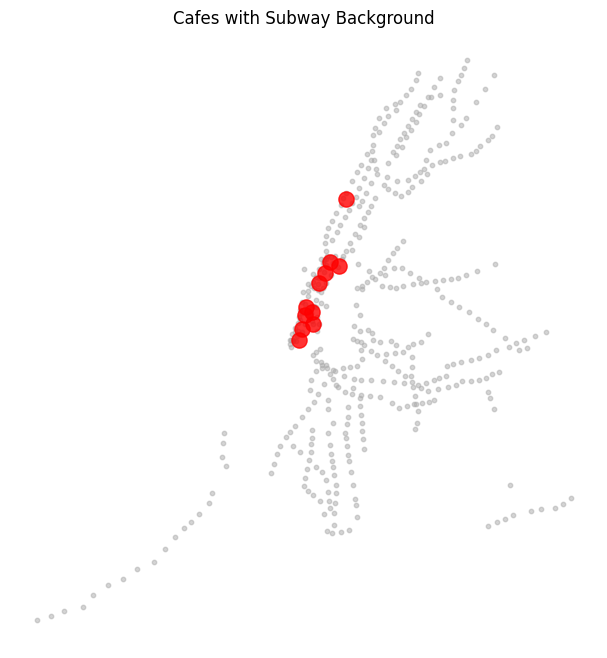

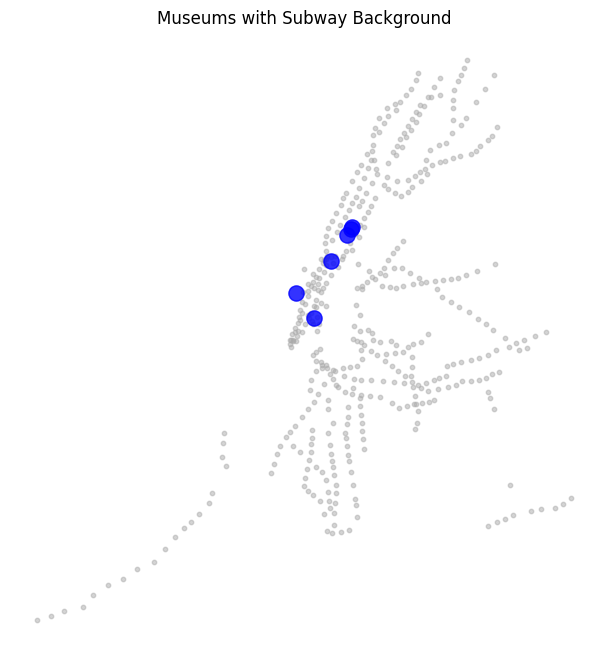

In [ ]:
ax = subway_with_rep_pt.plot(color="#ababab", figsize=(10, 8), markersize=10, alpha=0.5)
cafes_w_nearest_subway.plot(ax=ax, color="red", alpha=0.8, markersize=120)
plt.title("Cafes with Subway Background")
plt.show()

ax = subway_with_rep_pt.plot(color="#ababab", figsize=(10, 8), markersize=10, alpha=0.5)
museums_w_nearest_subway.plot(ax=ax, color="blue", alpha=0.8, markersize=120)
plt.title("Museums with Subway Background")
plt.show()

In [62]:
cafes_w_subway_clean = cafes_w_nearest_subway.drop(columns=["rep_pt"])

cafes_final = cafes.copy()
cafes_final = cafes_final.merge(
    cafes_w_subway_clean[["Stop Name", "Borough", "Daytime Routes", "distance"]],
    left_index=True,
    right_index=True,
    how="left",
)

print("Final cafes dataset:")
cafes_final.head()

Final cafes dataset:


,name,notes,geometry,Stop Name,Borough,Daytime Routes,distance
0,Conwell Coffee Hall,"Spacious, outlets, WiFi",POINT (-74.0062 40.7074),Wall St,M,2 3,0.002957
1,Bibliotheque,"Book-themed, WiFi, outlets",POINT (-74.0006 40.7242),Prince St,M,R W,0.002901
2,Caffe Reggio,"Historic cafe, classic vibe, WiFi",POINT (-74.0001 40.7301),W 4 St-Wash Sq,M,A C E B D F M,0.002273
3,The Hungarian Pastry Shop,"Cultural, writing atmosphere, no WiFi",POINT (-73.9637 40.8037),Cathedral Pkwy (110 St),M,1,0.003158
4,Remi Flowers & Coffee,"Flowers & coffee, quiet space",POINT (-73.9701 40.7579),Lexington Av/51-53 Sts,M,6 E M,0.000690


In [63]:
museums_w_subway_clean = museums_w_nearest_subway.drop(columns=["rep_pt"])

museums_final = museums.copy()
museums_final = museums_final.merge(
    museums_w_subway_clean[["Stop Name", "Borough", "Daytime Routes", "distance"]],
    left_index=True,
    right_index=True,
    how="left",
)

print("Final museums dataset:")
museums_final.head()

Final museums dataset:


,name,geometry,Stop Name,Borough,Daytime Routes,distance
0,MoMA,POINT (-73.9776 40.7614),57 St,M,F,0.002576
1,Whitney Museum,POINT (-74.0089 40.7396),14 St/8 Av,M,A C E L,0.006806
2,Guggenheim Museum,POINT (-73.959 40.783),86 St,M,4 5 6,0.004893
3,Cooper Hewitt Museum,POINT (-73.958 40.7844),86 St,M,4 5 6,0.005468
4,The Metropolitan Museum of Art,POINT (-73.9632 40.7794),77 St,M,6,0.006669


In [65]:
print("=== FINAL MERGED DATASETS ===")
print("Cafes columns:", cafes_final.columns.tolist())
print("Museums columns:", museums_final.columns.tolist())
print("\nCafes with nearest subway info:")
print(cafes_final[["name", "notes", "Stop Name", "distance"]].head())

=== FINAL MERGED DATASETS ===
Cafes columns: ['name', 'notes', 'geometry', 'Stop Name', 'Borough', 'Daytime Routes', 'distance']
Museums columns: ['name', 'geometry', 'Stop Name', 'Borough', 'Daytime Routes', 'distance']

Cafes with nearest subway info:
                        name                                  notes  \
0        Conwell Coffee Hall                Spacious, outlets, WiFi   
1               Bibliotheque             Book-themed, WiFi, outlets   
2               Caffe Reggio      Historic cafe, classic vibe, WiFi   
3  The Hungarian Pastry Shop  Cultural, writing atmosphere, no WiFi   
4      Remi Flowers & Coffee          Flowers & coffee, quiet space   

                 Stop Name  distance  
0                  Wall St  0.002957  
1                Prince St  0.002901  
2           W 4 St-Wash Sq  0.002273  
3  Cathedral Pkwy (110 St)  0.003158  
4   Lexington Av/51-53 Sts  0.000690  


In [66]:
cafe_cmap = {
    "Spacious, outlets, WiFi": "#ffff00",
    "Book-themed, WiFi, outlets": "#fffb00",
    "Historic cafe, classic vibe, WiFi": "#ffc800",
    "Cultural, writing atmosphere, no WiFi": "#ff4000",
    "Flowers & coffee, quiet space": "#ff0000",
    "Highly rated, study-friendly": "#7700ff",
    "Small, cozy, good coffee": "#808080",
    "Quick grab, busy area": "#001580",
    "Quiet study space": "#219F21",
    "Modern, trendy atmosphere": "#A6A6AB",
    "Traditional, local favorite": "#222222",
}

borough_cmap = {
    "M": "#ff0000",
    "BK": "#00ff00",
    "Q": "#0000ff",
    "BX": "#ffff00",
    "SI": "#ff00ff",
}

structure_cmap = {
    "Subway": "#808080",
    "Elevated": "#ff4000",
    "At Grade": "#219F21",
    "Open Cut": "#001580",
}

print("Color mappings created for:")
print("- Cafe types")
print("- Boroughs")
print("- Subway structure types")

Color mappings created for:
- Cafe types
- Boroughs
- Subway structure types


Similarly, we will convert the hex code-based cmap to the RGB-type representation that `lonboard` needs for visualizing


In [67]:
borough_cmap_rgb = {
    k: list(int(v[i : i + 2], 16) for i in (1, 3, 5)) for k, v in borough_cmap.items()
}

print("Borough colors in RGB:")
for borough, rgb in borough_cmap_rgb.items():
    print(f"{borough}: {rgb}")

Borough colors in RGB:
M: [255, 0, 0]
BK: [0, 255, 0]
Q: [0, 0, 255]
BX: [255, 255, 0]
SI: [255, 0, 255]


In [68]:
cafe_cmap_rgb = {
    k: list(int(v[i : i + 2], 16) for i in (1, 3, 5)) for k, v in cafe_cmap.items()
}

print("\nCafe colors in RGB:")
for note, rgb in cafe_cmap_rgb.items():
    print(f"{note}: {rgb}")


Cafe colors in RGB:
Spacious, outlets, WiFi: [255, 255, 0]
Book-themed, WiFi, outlets: [255, 251, 0]
Historic cafe, classic vibe, WiFi: [255, 200, 0]
Cultural, writing atmosphere, no WiFi: [255, 64, 0]
Flowers & coffee, quiet space: [255, 0, 0]
Highly rated, study-friendly: [119, 0, 255]
Small, cozy, good coffee: [128, 128, 128]
Quick grab, busy area: [0, 21, 128]
Quiet study space: [33, 159, 33]
Modern, trendy atmosphere: [166, 166, 171]
Traditional, local favorite: [34, 34, 34]


In [69]:
structure_cmap_rgb = {
    k: list(int(v[i : i + 2], 16) for i in (1, 3, 5)) for k, v in structure_cmap.items()
}

print("\nSubway structure colors in RGB:")
for structure, rgb in structure_cmap_rgb.items():
    print(f"{structure}: {rgb}")


Subway structure colors in RGB:
Subway: [128, 128, 128]
Elevated: [255, 64, 0]
At Grade: [33, 159, 33]
Open Cut: [0, 21, 128]


In [70]:
print("=== ALL RGB COLOR MAPPINGS ===")
print("Boroughs:", borough_cmap_rgb)
print("Cafe types:", cafe_cmap_rgb)
print("Subway structures:", structure_cmap_rgb)

=== ALL RGB COLOR MAPPINGS ===
Boroughs: {'M': [255, 0, 0], 'BK': [0, 255, 0], 'Q': [0, 0, 255], 'BX': [255, 255, 0], 'SI': [255, 0, 255]}
Cafe types: {'Spacious, outlets, WiFi': [255, 255, 0], 'Book-themed, WiFi, outlets': [255, 251, 0], 'Historic cafe, classic vibe, WiFi': [255, 200, 0], 'Cultural, writing atmosphere, no WiFi': [255, 64, 0], 'Flowers & coffee, quiet space': [255, 0, 0], 'Highly rated, study-friendly': [119, 0, 255], 'Small, cozy, good coffee': [128, 128, 128], 'Quick grab, busy area': [0, 21, 128], 'Quiet study space': [33, 159, 33], 'Modern, trendy atmosphere': [166, 166, 171], 'Traditional, local favorite': [34, 34, 34]}
Subway structures: {'Subway': [128, 128, 128], 'Elevated': [255, 64, 0], 'At Grade': [33, 159, 33], 'Open Cut': [0, 21, 128]}


In [72]:
cafes_final["Stop Name"].fillna("Unknown", inplace=True)
cafes_final["Borough"].fillna("Unknown", inplace=True)
cafes_final["Daytime Routes"].fillna("Unknown", inplace=True)

print("Cafes - NaN values filled with 'Unknown'")

museums_final["Stop Name"].fillna("Unknown", inplace=True)
museums_final["Borough"].fillna("Unknown", inplace=True)
museums_final["Daytime Routes"].fillna("Unknown", inplace=True)

print("Museums - NaN values filled with 'Unknown'")

cafes_final["notes"].fillna("No description", inplace=True)

print("Cafes notes - NaN values filled")

Cafes - NaN values filled with 'Unknown'
Museums - NaN values filled with 'Unknown'
Cafes notes - NaN values filled


/var/folders/44/049vwny176x1nrnv4c1p88r80000gn/T/ipykernel_70713/1313715717.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cafes_final["Stop Name"].fillna("Unknown", inplace=True)
/var/folders/44/049vwny176x1nrnv4c1p88r80000gn/T/ipykernel_70713/1313715717.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

Let's visually inspect the relationships between land use and color columns just to make sure things are mapped properly.


In [73]:
print("=== NaN Check After Filling ===")
print("Cafes NaN count:")
print(cafes_final.isnull().sum())

print("\nMuseums NaN count:")
print(museums_final.isnull().sum())

print("\nCafes Borough distribution:")
print(cafes_final["Borough"].value_counts())

print("\nMuseums Borough distribution:")
print(museums_final["Borough"].value_counts())

=== NaN Check After Filling ===
Cafes NaN count:
name              0
notes             0
geometry          0
Stop Name         0
Borough           0
Daytime Routes    0
distance          0
dtype: int64

Museums NaN count:
name              0
geometry          0
Stop Name         0
Borough           0
Daytime Routes    0
distance          0
dtype: int64

Cafes Borough distribution:
Borough
M    11
Name: count, dtype: int64

Museums Borough distribution:
Borough
M    6
Name: count, dtype: int64


In [76]:
borough_cmap_updated = {
    "M": "#ff0000",  # Manhattan - red
    "BK": "#00ff00",  # Brooklyn - green
    "Q": "#0000ff",  # Queens - blue
    "BX": "#ffff00",  # Bronx - yellow
    "SI": "#ff00ff",  # Staten Island - magenta
    "Unknown": "#000000",  # Unknown - black
}

In [78]:
print("borough_cmap_rgb keys:", list(borough_cmap_rgb.keys()))

print("\nBorough unique values:")
print("Cafes:", cafes_final["Borough"].unique())
print("Museums:", museums_final["Borough"].unique())
print("Subway:", subway_with_rep_pt["Borough"].unique())

borough_cmap_rgb = {
    k: list(int(v[i : i + 2], 16) for i in (1, 3, 5))
    for k, v in borough_cmap_updated.items()
}

print("borough_cmap_rgb keys:", list(borough_cmap_rgb.keys()))
print("RGB values:", borough_cmap_rgb)

borough_cmap_rgb keys: ['M', 'BK', 'Q', 'BX', 'SI']

Borough unique values:
Cafes: ['M']
Museums: ['M']
Subway: ['M' 'Bx' 'Q' 'SI' 'Bk']
borough_cmap_rgb keys: ['M', 'BK', 'Q', 'BX', 'SI', 'Unknown']
RGB values: {'M': [255, 0, 0], 'BK': [0, 255, 0], 'Q': [0, 0, 255], 'BX': [255, 255, 0], 'SI': [255, 0, 255], 'Unknown': [0, 0, 0]}


In [79]:
print("\n=== CAFE NOTES ANALYSIS ===")
print("Cafe notes unique values:")
print(cafes_final["notes"].unique())

if "cafe_cmap_rgb" in locals():
    print("cafe_cmap_rgb keys:", list(cafe_cmap_rgb.keys()))


=== CAFE NOTES ANALYSIS ===
Cafe notes unique values:
['Spacious, outlets, WiFi' 'Book-themed, WiFi, outlets'
 'Historic cafe, classic vibe, WiFi'
 'Cultural, writing atmosphere, no WiFi' 'Flowers & coffee, quiet space'
 'Highly rated, study-friendly' 'Cozy, WiFi, study-friendly'
 'Public study space, quiet, WiFi' 'Modern, spacious, WiFi'
 'Matcha specialist cafe, quiet, WiFi'
 'Quiet workspace, study-focused cafe']
cafe_cmap_rgb keys: ['Spacious, outlets, WiFi', 'Book-themed, WiFi, outlets', 'Historic cafe, classic vibe, WiFi', 'Cultural, writing atmosphere, no WiFi', 'Flowers & coffee, quiet space', 'Highly rated, study-friendly', 'Small, cozy, good coffee', 'Quick grab, busy area', 'Quiet study space', 'Modern, trendy atmosphere', 'Traditional, local favorite']


In [81]:
print("\n=== MAPPING CHECK ===")

cafe_boroughs = set(cafes_final["Borough"].unique())
mapped_boroughs = set(borough_cmap_updated.keys())
unmapped_cafe = cafe_boroughs - mapped_boroughs
if unmapped_cafe:
    print("Unmapped Borough values in cafes:", unmapped_cafe)
else:
    print("All cafe Borough values are mapped")

museum_boroughs = set(museums_final["Borough"].unique())
unmapped_museum = museum_boroughs - mapped_boroughs
if unmapped_museum:
    print("Unmapped Borough values in museums:", unmapped_museum)
else:
    print("All museum Borough values are mapped")


=== MAPPING CHECK ===
All cafe Borough values are mapped
All museum Borough values are mapped


In [82]:
import plotly.graph_objects as go
import plotly.express as px

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=cafes_final.geometry.x,
        y=cafes_final.geometry.y,
        z=[10] * len(cafes_final),
        mode="markers",
        marker=dict(
            size=10,
            color=[borough_cmap_updated[b] for b in cafes_final["Borough"]],
            opacity=0.8,
        ),
        text=cafes_final["name"],
        name="Cafes",
    )
)

fig.add_trace(
    go.Scatter3d(
        x=museums_final.geometry.x,
        y=museums_final.geometry.y,
        z=[15] * len(museums_final),
        mode="markers",
        marker=dict(
            size=12,
            color=[borough_cmap_updated[b] for b in museums_final["Borough"]],
            symbol="square",
            opacity=0.8,
        ),
        text=museums_final["name"],
        name="Museums",
    )
)

fig.update_layout(
    scene=dict(xaxis_title="Longitude", yaxis_title="Latitude", zaxis_title="Height"),
    title="3D Daily Life Data",
)

fig.show()

In [85]:
cafes_unique_stations = cafes_final["Stop Name"].nunique()
total_subway_stations = subway_with_rep_pt.shape[0]

print("Cafes analysis:")
print(f"Unique subway stations near cafes: {cafes_unique_stations}")
print(f"Total subway stations in area: {total_subway_stations}")
print(f"Coverage ratio: {cafes_unique_stations/total_subway_stations:.2%}")

Cafes analysis:
Unique subway stations near cafes: 11
Total subway stations in area: 442
Coverage ratio: 2.49%


In [86]:
museums_unique_stations = museums_final["Stop Name"].nunique()

print("\nMuseums analysis:")
print(f"Unique subway stations near museums: {museums_unique_stations}")
print(f"Total subway stations in area: {total_subway_stations}")
print(f"Coverage ratio: {museums_unique_stations/total_subway_stations:.2%}")


Museums analysis:
Unique subway stations near museums: 5
Total subway stations in area: 442
Coverage ratio: 1.13%


In [87]:
all_places_stations = set(
    cafes_final["Stop Name"].tolist() + museums_final["Stop Name"].tolist()
)
all_unique_stations = len(all_places_stations)

print("\nCombined analysis:")
print(f"All unique stations used by cafes & museums: {all_unique_stations}")
print(f"Total subway stations in area: {total_subway_stations}")
print(f"Overall coverage ratio: {all_unique_stations/total_subway_stations:.2%}")


Combined analysis:
All unique stations used by cafes & museums: 16
Total subway stations in area: 442
Overall coverage ratio: 3.62%


In [88]:
print("=== DATA TYPES ANALYSIS ===")

print("Cafes data types:")
print(f"name: {cafes_final['name'].dtype}")
print(f"Borough: {cafes_final['Borough'].dtype}")
print(f"Stop Name: {cafes_final['Stop Name'].dtype}")
print(f"distance: {cafes_final['distance'].dtype}")

print("\nSubway data types:")
print(f"Stop Name: {subway_with_rep_pt['Stop Name'].dtype}")
print(f"Borough: {subway_with_rep_pt['Borough'].dtype}")
print(f"Complex ID: {subway_with_rep_pt['Complex ID'].dtype}")

=== DATA TYPES ANALYSIS ===
Cafes data types:
name: object
Borough: object
Stop Name: object
distance: float64

Subway data types:
Stop Name: object
Borough: object
Complex ID: object


In [89]:
try:
    subway_with_rep_pt["Complex ID"] = subway_with_rep_pt["Complex ID"].astype(float)
    print("Complex ID converted to float successfully")
    print(f"New Complex ID dtype: {subway_with_rep_pt['Complex ID'].dtype}")
except:
    print("Complex ID conversion failed, keeping as object")

Complex ID converted to float successfully
New Complex ID dtype: float64


In [90]:
cafes_w_subway_attrib = cafes_final.merge(
    subway_with_rep_pt,
    left_on="Stop Name",
    right_on="Stop Name",
    how="inner",
    suffixes=["_cafe", "_subway"],
)

print("Cafes merged with subway attributes:")
print(f"Shape: {cafes_w_subway_attrib.shape}")
print("Columns:", cafes_w_subway_attrib.columns.tolist())

Cafes merged with subway attributes:
Shape: (16, 24)
Columns: ['name', 'notes', 'geometry_cafe', 'Stop Name', 'Borough_cafe', 'Daytime Routes_cafe', 'distance', 'Complex ID', 'Is Complex', 'Number Of Stations In Complex', 'Display Name', 'Constituent Station Names', 'Station IDs', 'GTFS Stop IDs', 'Borough_subway', 'CBD', 'Daytime Routes_subway', 'Structure Type', 'Latitude', 'Longitude', 'ADA', 'ADA Notes', 'geometry_subway', 'rep_pt']


In [91]:
museums_w_subway_attrib = museums_final.merge(
    subway_with_rep_pt,
    left_on="Stop Name",
    right_on="Stop Name",
    how="inner",
    suffixes=["_museum", "_subway"],
)

print("\nMuseums merged with subway attributes:")
print(f"Shape: {museums_w_subway_attrib.shape}")
print("Columns:", museums_w_subway_attrib.columns.tolist())


Museums merged with subway attributes:
Shape: (17, 23)
Columns: ['name', 'geometry_museum', 'Stop Name', 'Borough_museum', 'Daytime Routes_museum', 'distance', 'Complex ID', 'Is Complex', 'Number Of Stations In Complex', 'Display Name', 'Constituent Station Names', 'Station IDs', 'GTFS Stop IDs', 'Borough_subway', 'CBD', 'Daytime Routes_subway', 'Structure Type', 'Latitude', 'Longitude', 'ADA', 'ADA Notes', 'geometry_subway', 'rep_pt']


In [92]:
cafes_w_subway_attrib.head()
museums_w_subway_attrib.head()

,name,geometry_museum,Stop Name,Borough_museum,Daytime Routes_museum,distance,Complex ID,Is Complex,Number Of Stations In Complex,Display Name,...,Borough_subway,CBD,Daytime Routes_subway,Structure Type,Latitude,Longitude,ADA,ADA Notes,geometry_subway,rep_pt
0,MoMA,POINT (-73.9776 40.7614),57 St,M,F,0.002576,224.0,False,1,57 St (F),...,M,True,F,Subway,40.763972,-73.97745,0,,POINT (-73.97745 40.76397),POINT (-73.97745 40.76397)
1,Whitney Museum,POINT (-74.0089 40.7396),14 St/8 Av,M,A C E L,0.006806,618.0,True,2,"14 St/8 Av (A,C,E,L)",...,M,True,A C E L,Subway,40.740335,-74.002134,1,,POINT (-74.00213 40.74034),POINT (-74.00213 40.74034)
2,Guggenheim Museum,POINT (-73.959 40.783),86 St,M,4 5 6,0.004893,476.0,False,1,86 St (Q),...,M,False,Q,Subway,40.777891,-73.951787,1,,POINT (-73.95179 40.77789),POINT (-73.95179 40.77789)
3,Guggenheim Museum,POINT (-73.959 40.783),86 St,M,4 5 6,0.004893,311.0,False,1,86 St (1),...,M,False,1,Subway,40.788644,-73.976218,0,,POINT (-73.97622 40.78864),POINT (-73.97622 40.78864)
4,Guggenheim Museum,POINT (-73.959 40.783),86 St,M,4 5 6,0.004893,397.0,False,1,"86 St (4,5,6)",...,M,False,4 5 6,Subway,40.779492,-73.955589,2,Uptown local only,POINT (-73.95559 40.77949),POINT (-73.95559 40.77949)


In [93]:
spatial_join_rows = cafes_w_nearest_subway.shape[0]
attribute_merge_rows = cafes_w_subway_attrib.shape[0]

print("=== CAFES ROW COUNT COMPARISON ===")
print(f"Spatial join result: {spatial_join_rows}")
print(f"Attribute merge result: {attribute_merge_rows}")
print(f"Rows are equal: {spatial_join_rows == attribute_merge_rows}")

=== CAFES ROW COUNT COMPARISON ===
Spatial join result: 11
Attribute merge result: 16
Rows are equal: False


In [94]:
museum_spatial_rows = museums_w_nearest_subway.shape[0]
museum_merge_rows = museums_w_subway_attrib.shape[0]

print("\n=== MUSEUMS ROW COUNT COMPARISON ===")
print(f"Spatial join result: {museum_spatial_rows}")
print(f"Attribute merge result: {museum_merge_rows}")
print(f"Rows are equal: {museum_spatial_rows == museum_merge_rows}")


=== MUSEUMS ROW COUNT COMPARISON ===
Spatial join result: 6
Attribute merge result: 17
Rows are equal: False


In [95]:
print(
    f"There are {cafes_w_subway_attrib.shape[0]} features in the attribute join dataset\n"
    f"and {cafes_w_nearest_subway.shape[0]} features in the spatial join dataset"
)

There are 16 features in the attribute join dataset
and 11 features in the spatial join dataset


In [96]:
print(
    f"\nMuseums:\n"
    f"There are {museums_w_subway_attrib.shape[0]} features in the attribute join dataset\n"
    f"and {museums_w_nearest_subway.shape[0]} features in the spatial join dataset"
)


Museums:
There are 17 features in the attribute join dataset
and 6 features in the spatial join dataset


Available geometry columns in cafes_w_subway_attrib:
['geometry_cafe', 'geometry_subway']
Active geometry set to 'geometry_cafe'


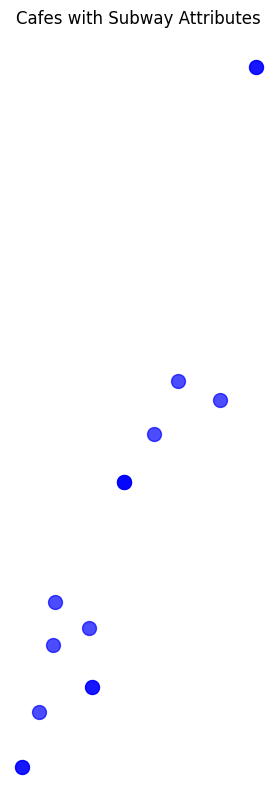

In [ ]:
print("Available geometry columns in cafes_w_subway_attrib:")
geom_cols = [col for col in cafes_w_subway_attrib.columns if "geometry" in col.lower()]
print(geom_cols)

cafes_w_subway_attrib = cafes_w_subway_attrib.set_geometry("geometry_cafe")
print("Active geometry set to 'geometry_cafe'")

ax = cafes_w_subway_attrib.plot(
    figsize=(12, 10), color="blue", markersize=100, alpha=0.7
)
plt.title("Cafes with Subway Attributes")
plt.show()

All cafes from attribute merge are also in spatial join


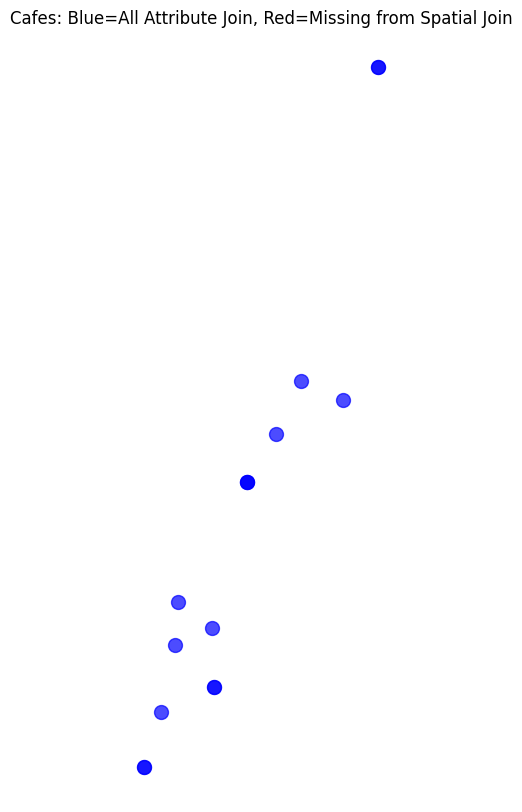

In [99]:
ax = cafes_w_subway_attrib.plot(
    figsize=(12, 10), color="blue", markersize=100, alpha=0.7
)

missing_in_spatial = cafes_w_subway_attrib[
    ~cafes_w_subway_attrib["name"].isin(cafes_w_nearest_subway["name"])
]

if len(missing_in_spatial) > 0:
    missing_in_spatial.plot(ax=ax, color="red", markersize=150, alpha=0.9)
    print(
        f"Found {len(missing_in_spatial)} cafes in attribute merge but not in spatial join:"
    )
    print(missing_in_spatial["name"].tolist())
else:
    print("All cafes from attribute merge are also in spatial join")

plt.title("Cafes: Blue=All Attribute Join, Red=Missing from Spatial Join")
plt.show()

Museums geometry columns:
['geometry_museum', 'geometry_subway']
All museums are consistent between joins


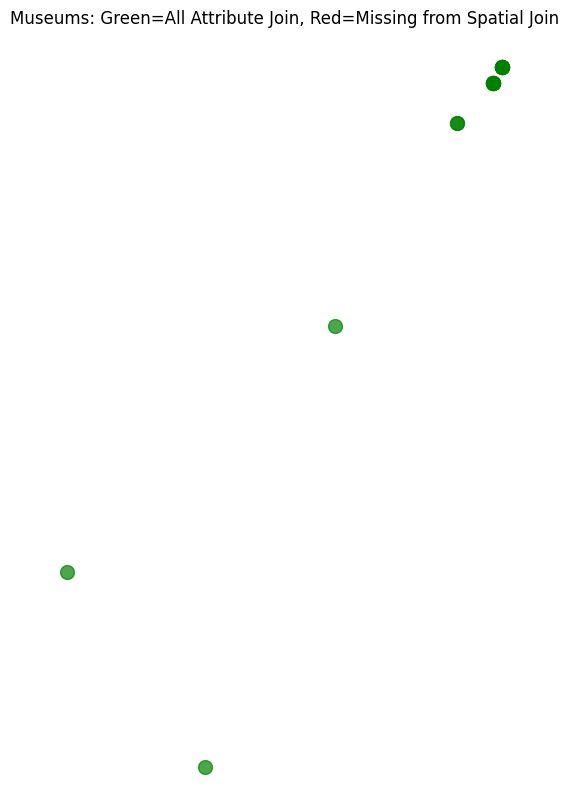

In [100]:
print("Museums geometry columns:")
museum_geom_cols = [
    col for col in museums_w_subway_attrib.columns if "geometry" in col.lower()
]
print(museum_geom_cols)

museums_w_subway_attrib = museums_w_subway_attrib.set_geometry("geometry_museum")

ax = museums_w_subway_attrib.plot(
    figsize=(12, 10), color="green", markersize=100, alpha=0.7
)

missing_museums = museums_w_subway_attrib[
    ~museums_w_subway_attrib["name"].isin(museums_w_nearest_subway["name"])
]

if len(missing_museums) > 0:
    missing_museums.plot(ax=ax, color="red", markersize=150, alpha=0.9)
    print(
        f"Found {len(missing_museums)} museums in attribute merge but not in spatial join"
    )
else:
    print("All museums are consistent between joins")

plt.title("Museums: Green=All Attribute Join, Red=Missing from Spatial Join")
plt.show()

In [101]:
missing_cafes = cafes_w_subway_attrib[
    ~cafes_w_subway_attrib["name"].isin(cafes_w_nearest_subway["name"])
].copy()

print(f"Missing cafes count: {len(missing_cafes)}")
if len(missing_cafes) > 0:
    print("Missing cafes:", missing_cafes["name"].tolist())
else:
    print("No missing cafes found")

Missing cafes count: 0
No missing cafes found


In [102]:
missing_cafes.shape[0]

0

In [103]:
cafes_w_subway_attrib.set_geometry("geometry_cafe", inplace=True)
museums_w_subway_attrib.set_geometry("geometry_museum", inplace=True)

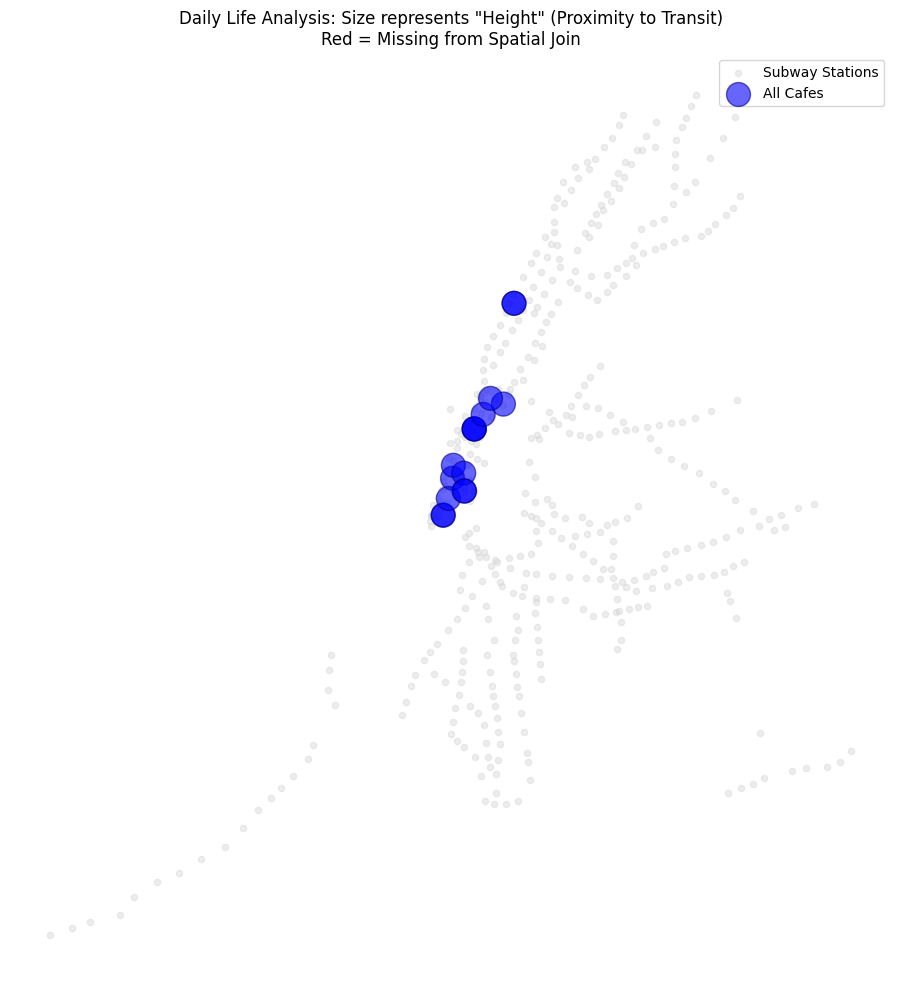

In [104]:
fig, ax = plt.subplots(figsize=(15, 12))

subway_with_rep_pt.plot(
    ax=ax, color="lightgray", markersize=20, alpha=0.4, label="Subway Stations"
)

if "distance" in cafes_w_subway_attrib.columns:
    sizes = 300 - (cafes_w_subway_attrib["distance"] * 2000)
    sizes = sizes.clip(50, 300)
else:
    sizes = 150

cafes_w_subway_attrib.plot(
    ax=ax,
    color="blue",
    markersize=sizes,
    alpha=0.6,
    label="All Cafes",
    edgecolor="darkblue",
)

if len(missing_cafes) > 0:
    if "distance" in missing_cafes.columns:
        missing_sizes = 400 - (missing_cafes["distance"] * 2000)
        missing_sizes = missing_sizes.clip(100, 400)
    else:
        missing_sizes = 250

    missing_cafes.plot(
        ax=ax,
        color="red",
        markersize=missing_sizes,
        alpha=0.9,
        label="Missing from Spatial Join",
        edgecolor="darkred",
        linewidth=2,
    )

plt.legend()
plt.title(
    'Daily Life Analysis: Size represents "Height" (Proximity to Transit)\nRed = Missing from Spatial Join'
)
plt.show()

In [105]:
subway_by_routes = subway_with_rep_pt.dissolve(
    by="Daytime Routes",
    aggfunc={
        "Stop Name": list,
        "Borough": list,
        "Structure Type": list,
    },
    as_index=False,
)

print("Subway stations grouped by routes:")
print(f"Shape: {subway_by_routes.shape}")
print("Columns:", subway_by_routes.columns.tolist())

Subway stations grouped by routes:
Shape: (93, 5)
Columns: ['Daytime Routes', 'rep_pt', 'Stop Name', 'Borough', 'Structure Type']


Let's take a look at the top ten owners with the greatest total lot area.


In [110]:
import pandas as pd

route_counts = (
    subway_with_rep_pt.groupby("Daytime Routes")
    .size()
    .reset_index(name="station_count")
)
print("Top routes by station count:")
print(route_counts.sort_values("station_count", ascending=False).head(10))

cafe_station_counts = (
    cafes_w_subway_attrib.groupby("Stop Name")["name"]
    .count()
    .reset_index(name="cafe_count")
)
print("\nStations with most cafes:")
print(cafe_station_counts.sort_values("cafe_count", ascending=False).head(10))

Top routes by station count:
   Daytime Routes  station_count
0               1             29
27              6             29
15            2 5             25
67              F             20
36              A             20
92            SIR             20
77              L             18
31              7             16
56              D             12
88              Q             12

Stations with most cafes:
                                Stop Name  cafe_count
0                                   28 St           3
5                 Cathedral Pkwy (110 St)           2
6                                Grand St           2
10                                Wall St           2
1                    42 St-Bryant Pk/5 Av           1
2                              5 Av/53 St           1
3       Broadway-Lafayette St/Bleecker St           1
4   Brooklyn Bridge-City Hall/Chambers St           1
7                  Lexington Av/51-53 Sts           1
8                               Prince St

In [116]:
subway_by_routes = (
    subway_with_rep_pt.groupby("Daytime Routes")
    .agg({"Complex ID": "count", "Stop Name": list, "Borough": list})
    .reset_index()
)

print("✓ subway_by_routes created")
print(f"Shape: {subway_by_routes.shape}")
print("Columns:", subway_by_routes.columns.tolist())

✓ subway_by_routes created
Shape: (93, 4)
Columns: ['Daytime Routes', 'Complex ID', 'Stop Name', 'Borough']


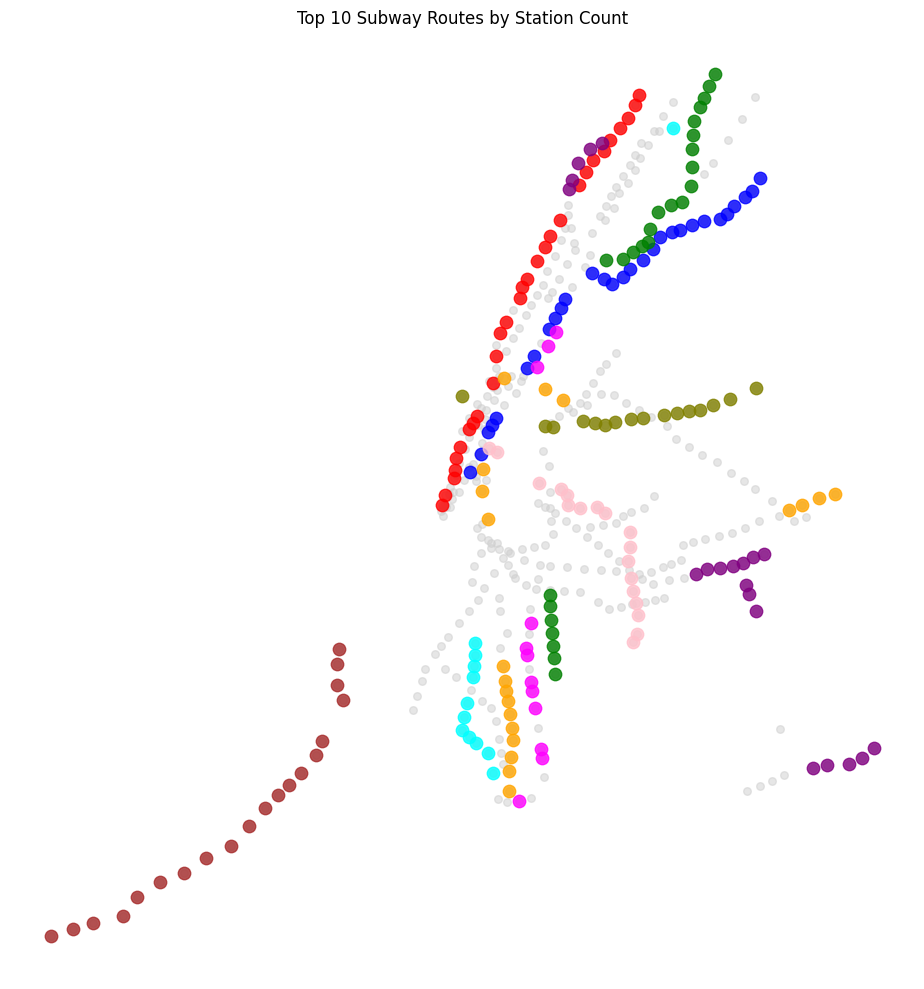

In [117]:
fig, ax = plt.subplots(figsize=(15, 10))

subway_with_rep_pt.plot(color="#cecece", ax=ax, alpha=0.5, markersize=30)

top_routes = subway_by_routes.sort_values("Complex ID", ascending=False).head(10)

colors = [
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "brown",
    "pink",
    "olive",
    "cyan",
    "magenta",
]

for i, (idx, route_data) in enumerate(top_routes.iterrows()):
    route_name = route_data["Daytime Routes"]
    route_stations = subway_with_rep_pt[
        subway_with_rep_pt["Daytime Routes"] == route_name
    ]

    if len(route_stations) > 0:
        route_stations.plot(
            ax=ax,
            color=colors[i % len(colors)],
            markersize=80,
            alpha=0.8,
            label=f"{route_name} ({len(route_stations)} stations)",
        )

leg = ax.get_legend()
if leg:
    leg.set_bbox_to_anchor((1.05, 1.0))

ax.set_title("Top 10 Subway Routes by Station Count")
plt.tight_layout()
plt.show()

In [119]:
sample_route = subway_with_rep_pt["Daytime Routes"].sample(1).values[0]
print(f"Selected sample route: {sample_route}")

sample_cafe = cafes_w_subway_attrib["name"].sample(1).values[0]
print(f"Selected sample cafe: {sample_cafe}")

Selected sample route: A
Selected sample cafe: Conwell Coffee Hall


In [120]:
sample_route_stations = subway_with_rep_pt[
    subway_with_rep_pt["Daytime Routes"].eq(sample_route)
].copy()

sample_route_cafes = cafes_w_subway_attrib[
    cafes_w_subway_attrib["Stop Name"].isin(sample_route_stations["Stop Name"].unique())
].copy()

print(f"Sample route: {sample_route}")
print(f"Stations in this route: {len(sample_route_stations)}")
print(f"Cafes using these stations: {len(sample_route_cafes)}")

Sample route: A
Stations in this route: 20
Cafes using these stations: 0


In [121]:
sample_route_cafes.set_geometry("geometry_cafe", inplace=True)

/var/folders/44/049vwny176x1nrnv4c1p88r80000gn/T/ipykernel_70713/2989460022.py:19: UserWarning:

The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.



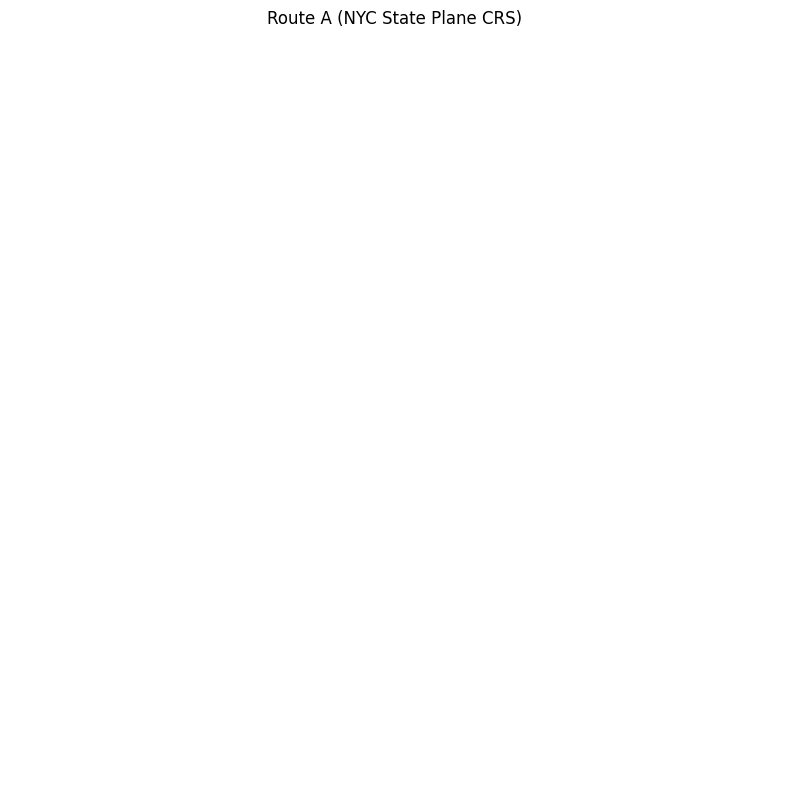

In [124]:
# NYC State Plane 좌표계 사용 (더 정확한 거리 계산)
nyc_crs = "EPSG:2263"  # NAD83 / New York Long Island (ftUS)

# 모든 데이터를 NYC CRS로 변환
sample_route_stations_nyc = sample_route_stations.to_crs(nyc_crs)
sample_route_cafes_nyc = (
    sample_route_cafes.to_crs(nyc_crs)
    if len(sample_route_cafes) > 0
    else gpd.GeoDataFrame()
)

# 피트 단위로 버퍼 (NYC CRS는 피트 단위)
sample_route_stations_buffered_nyc = sample_route_stations_nyc.copy()
sample_route_stations_buffered_nyc["geometry"] = (
    sample_route_stations_buffered_nyc.geometry.buffer(500)
)  # 500피트

# 시각화
ax = sample_route_stations_buffered_nyc.boundary.plot(
    color="black", linewidth=0.5, figsize=(12, 10)
)

if len(sample_route_cafes_nyc) > 0:
    sample_route_cafes_nyc.plot(ax=ax, color="red", markersize=120, alpha=0.8)

ax.set_title(f"Route {sample_route} (NYC State Plane CRS)")
plt.show()

Next we can identify the portions of the block that are _not_ buildings by calculating the `difference` between the lots and the buildings. We will use the `unary_union` property of the buildings dataframe, which represents a [union of all geometries in the dataframe](https://geopandas.org/en/v0.10.0/docs/reference/api/geopandas.GeoSeries.unary_union.html). It is essentially a shortcut to a dissolve of all geometries in a dataframe.

With these chained commands, we will return the area of each tax lot that is not a building.


In [ ]:
sample_block_non_bldg = sample_block_lots.difference(sample_block_bldgs.unary_union)

/var/folders/44/049vwny176x1nrnv4c1p88r80000gn/T/ipykernel_66573/3284385118.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  sample_block_non_bldg = sample_block_lots.difference(sample_block_bldgs.unary_union)


We can plot the results to confirm that each lot still exists as its own feature (blue with black outlines) and are separate from the orange building polygons. Note that in some cases, lots may be split into two distinct areas, making them _MultiPolygons_.


<Axes: >

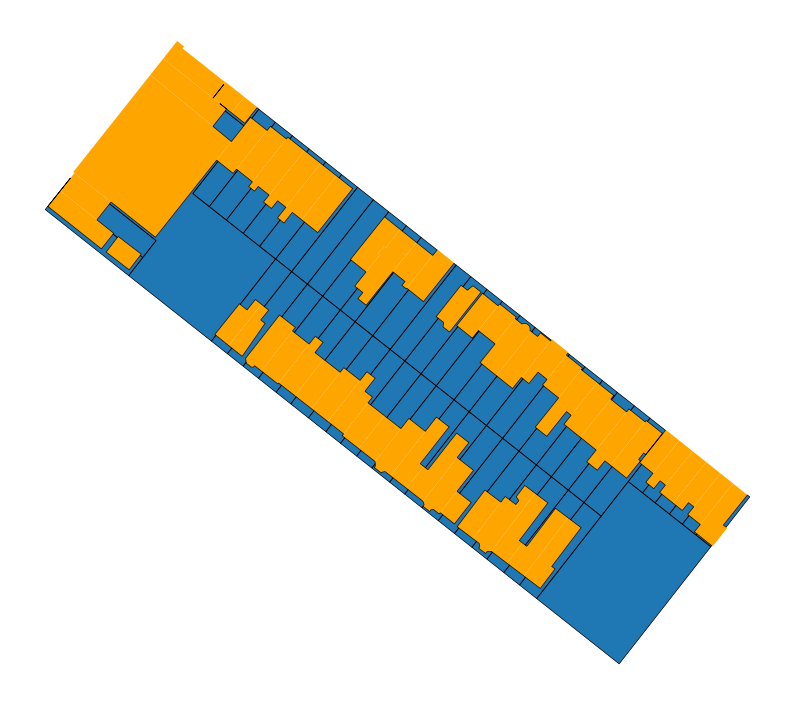

In [ ]:
ax = sample_block_non_bldg.boundary.plot(color="black", linewidth=0.5)
sample_block_non_bldg.plot(ax=ax)
sample_block_bldgs.plot(ax=ax, color="orange")

We could use this new dataset to calculate the _lot coverage_ of each lot, which could be useful in a soft site analysis (continued below). Next we will explore another means of calculating lot coverage by _unioning_ features instead of taking the intersection.


## Union


We'll continue using the sample block we identified above. We'll start by calculating the lot area of each lot in our sample.


In [ ]:
sample_block_lots["lot_area"] = sample_block_lots.area

Now we'll perform a _union_ between the lots and the building footprints. A union, like the _difference_ performed above, is a kind of _overlay_ method that we can apply between multiple dataframes. (For more information on other overlay methods, check out [the documentation](https://geopandas.org/en/v0.10.0/docs/user_guide/set_operations.html)). The `union` operation retains all geometry of the input layers, as well as the attributes of each based on the overlap.

<img src="https://geopandas.org/en/v0.10.0/_images/overlay_operations.png" alt="Geopandas overlay operations" width="600"/>

_Source: QGIS Documentation via Geopandas docs_

A union would take the following input:

<img src="https://geopandas.org/en/v0.10.0/_images/overlay_example.png" alt="Geopandas overlay operations" width="600"/>

and produce the following output:

<img src="https://geopandas.org/en/v0.10.0/_images/overlay_example_union.png" alt="Geopandas overlay operations" width="600"/>


In [ ]:
lots_bldgs_union = gpd.overlay(sample_block_lots, sample_block_bldgs, how="union")

A union will produce features that have geometry entries (based on the union operation), as well as attributes from both input datasets _so long as there is coverage of that dataset_. In our example, there will be full attributes of both datasets for the portion of the lots that are buildings, but the other portions of lots will not have attributes from the buildings dataset.


In [ ]:
lots_bldgs_union.head()

We can illustrate that point by mapping the output layer. In the below example, we filter for cases where the `globalid` (which is associated with the buildings dataset) is null (`.isna()`) in grey. Cases where the `globalid` is _not_ null are red.


In [ ]:
ax = lots_bldgs_union[lots_bldgs_union.globalid.isna()].plot(color="#cecece")
lots_bldgs_union[lots_bldgs_union.globalid.notna()].plot(ax=ax, color="red")

We can also plot based on a shared attribute to demonstrate that both portions of the lots (building and non-building) are part of the same lot. Plotting the boundary separately confirms that each segment of the building/lot combination is in fact a separate feature.


In [ ]:
ax = lots_bldgs_union[lots_bldgs_union.globalid.isna()].plot("Lot")
lots_bldgs_union[lots_bldgs_union.globalid.notna()].plot("Lot", ax=ax)
lots_bldgs_union.boundary.plot(color="black", ax=ax, linewidth=0.5)

Finally, we can create a new attribute field that represents the _percent of the lot that is covered by a building_ as discussed above. The below operation uses a _lambda_ function, which is a way to iterate through a dataframe and perform a calculation on each row (or column, based on the `axis=...` argument). The function can be understood as follows:

- `lambda x: ... axis=1` for each row (`x`, based on the `1` axis value), perform the following operation
- `((x.geometry.area / x.lot_area)*100...)`: take the geometry of each piece of the unioned dataframe, calculate the area, divide it by the lot area (which we calculated above, pre-union), and multiply by 100 to get a percentage
- `if type(x.globalid) == str else -1`: only do this for the input features that are pieces of buildings (e.g. they have a `globalid`), otherwise return a placeholder value of `-1`. This number is negative on purpose so it is easy to filter out, but you could also use `None` or `NaN` if you prefer.

As you can see, we can perform a multi-step operation using a `lambda` function. For more complex operations, it makes sense to write standalone functions for legibility- we'll demonstrate that in the following section. There is no hard rule for legibility vs. brevity (i.e. lambda vs standalone functions), so use your best judgement. What's important is that you or your user understand what the code is doing.


In [ ]:
lots_bldgs_union["pct_bldg_lot_coverage"] = lots_bldgs_union.apply(
    lambda x: ((x.geometry.area / x.lot_area) * 100 if type(x.globalid) == str else -1),
    axis=1,
)

Now let's plot and see the percentage of each lot that is covered by buildings. This could be expressed in a number of different ways (e.g. at the lot level) but we can get a sense of the utility of the `union` operation.


In [ ]:
lots_bldgs_union.plot("pct_bldg_lot_coverage", legend=True)

## Creating new attributes


In this example, we'll develop a function that indicates whether a site is a "soft site" or not. A "soft site" is a site that meets certain criteria for redevelopment. The factors below represent just a few of the considerations that are often taken to determine whether a site may be a good candidate for redevelopment, but this is a simplistic example case to illustrate a point rather than a firm ruleset.


Because we are considering a few different factors, we will write a new _function_ vs. chaining criteria together in a `lambda` function (although you could use the same kind of syntax above to perform the same work).

There are several important components to consider.

`def [function_name]([input_args...]):`
The instantiation of the function is important. We are _defining_ (`def`) a new function, giving it a name (in this case, `is_soft_site`), and indicating that there are two possible input arguments: `r`, which is a common shorthand for a row in a dataset, and the optional argument `threshold`. This is _optional_ and comes with a default value of `0.33`, meaning that if a user doesn't specify a threshold, `0.33` will be used. You could imagine other cases where required or optional arguments might be useful!

`if (...): return 1 else: return 0`
This is the part of the function that is evaluating properties of our input `r` based on it's properties. We can see the evaluation of its `BuiltFAR` compared to the lot's `ResidFAR` (allowed residential FAR) times the `threshold` set here. We are determining whether the site is built less than or equal to 33% of the allowable residential FAR.

We then evaluate the lot area, existing land use, and whether there is available residential FAR at all to indicate that yes, this is a soft site, or no, it is not. The `return` statements are what pass that information back to us: if those conditions are met, we get a `1`, otherwise a `0`.

Functions don't necessarily have to return anything, but in this case we will be using this logic to create a new field and so want to be sure that _something_ is always returned.


In [ ]:
def is_soft_site(r, threshold=0.33):
    if (
        r.BuiltFAR <= r.ResidFAR * threshold
        and r.LotArea > 10000
        and r.LandUse != "Open Space & Outdoor Recreation"
        and r.ResidFAR > 0
    ):
        return 1
    else:
        return 0

We can invoke the function using the `apply()` method- here we pass in the function name, and specify that we want to apply the function to each _row_ (`axis=1`) vs each _column_ (`axis=0`) of our table.

If we wanted to pass in a `threshold` value, we could pass in a tuple of arguments: `...apply(is_soft_site, axis=1, args=(0.5,))` which is then passed in as a different threshold. Part of the point of providing these optional attributes is to make it easier for you / your users to make changes quickly- in a more complex example you might also have arguments for your lot area thresholds, the land uses that are off limits, etc.


In [ ]:
cb_307["soft_site"] = cb_307.apply(is_soft_site, axis=1)

Now let's check how many soft sites we have in the neighborhood based on the criteria we defined above. Because we use 1/0 values to distinguish soft sites from not, we can use the `value_counts()` method to get a quick overview of the number of soft sites in the neighborhood.


In [ ]:
cb_307["soft_site"].value_counts()

Now let's create a quick map to see where our soft sites are. What do you notice about the distribution of sites?


In [ ]:
ax = cb_307.plot(color="#cecece", alpha=0.5)
cb_307[cb_307.soft_site > 0].plot("soft_site", ax=ax, legend=True, categorical=True)
plt.title("Soft Sites in Community Board 307")

In [ ]:
cb_307[cb_307.soft_site.eq(1)][["soft_site", "BuiltFAR", "ResidFAR"]]

In [ ]:
# map soft sites
soft_sites = cb_307[cb_307.soft_site.eq(1)].copy().to_crs("EPSG:4326")
soft_sites["ResidFAR"]

lots_layer = PolygonLayer.from_geopandas(
    soft_sites[["geometry", "ResidFAR"]],
    extruded=True,
    get_elevation=soft_sites["ResidFAR"] * 15,  # scale elevation for visibility
    pickable=True,
)

base_layer = PolygonLayer.from_geopandas(
    cb_307[["geometry", "LandUse"]].to_crs("EPSG:4326"),
    get_fill_color=[200, 200, 200, 155],
)

m = Map(
    [base_layer, lots_layer],
    view_state={
        "pitch": 45,
        "zoom": 14,
        "latitude": 40.6459406,
        "longitude": -74.0151512,
    },
)
m